In [1]:
import pandas as pd

df = pd.read_csv("../data/Q2_TRAITS_V_PLACEMENT.csv")

df_transactions = (
    df.groupby(["match_id", "puuid"])["trait_name"]
      .apply(list)               
      .reset_index(name="traits")  
)

print(df_transactions.head())

transactions_list = df_transactions["traits"].tolist()
print(transactions_list[:5])  


         match_id                                              puuid  \
0  NA1_5207953898  1x8SiuU29wBehu4HwldU0tiLaoeYZKkyJatYg12fu8a56P...   
1  NA1_5207953898  23nlj-mOFFeTPgkfSkE7oM0vXUkDvtCrUT9qt-NwnnhWav...   
2  NA1_5207953898  43332cvV4A2mqb2W0JfRmsfY9djf-VGUgRyPY4wB0BLbtw...   
3  NA1_5207953898  7iIW7cDfdPzm9o3z0uea93AooftwLNn9OHAvQ79gKJOUHG...   
4  NA1_5207953898  FCVNYmfyGJb7c4xAU_CDzVjrFzXapffhOPPn6lXfE8Cmtt...   

                                              traits  
0  [TFT13_Ambusher, TFT13_Bruiser, TFT13_Challeng...  
1  [TFT13_Ambassador, TFT13_Bruiser, TFT13_Cabal,...  
2  [TFT13_Academy, TFT13_Hextech, TFT13_Invoker, ...  
3  [TFT13_Academy, TFT13_Ambassador, TFT13_Bruise...  
4  [TFT13_Academy, TFT13_Ambassador, TFT13_Crime,...  
[['TFT13_Ambusher', 'TFT13_Bruiser', 'TFT13_Challenger', 'TFT13_Hoverboard', 'TFT13_Invoker', 'TFT13_JunkerKing', 'TFT13_Martialist', 'TFT13_Pugilist', 'TFT13_Scrap', 'TFT13_Sniper', 'TFT13_Squad', 'TFT13_Teamup_Reunion', 'TFT13_Titan'],

In [2]:
df_transactions_only = df_transactions.drop(['match_id', 'puuid'], axis=1)

In [4]:
df_transactions_only.to_csv("../data/trait_transactions.csv", index=False)

In [7]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_array = te.fit(transactions_list).transform(transactions_list)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.4, use_colnames=True)

print("Frequent itemsets (min support=0.4):")
print(frequent_itemsets)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)

print("\nAssociation rules with min confidence of 0.4:")
print(rules)

Frequent itemsets (min support=0.4):
     support                                         itemsets
0   0.585903                               (TFT13_Ambassador)
1   0.676542                                  (TFT13_Bruiser)
2   0.632337                                    (TFT13_Cabal)
3   0.424963                               (TFT13_Experiment)
4   0.654532                              (TFT13_FormSwapper)
5   0.455145                                  (TFT13_Invoker)
6   0.466196                               (TFT13_Martialist)
7   0.472233                                 (TFT13_Pugilist)
8   0.528789                                    (TFT13_Rebel)
9   0.582652                                    (TFT13_Scrap)
10  0.442608                                 (TFT13_Sorcerer)
11  0.436757                                    (TFT13_Squad)
12  0.592589                                    (TFT13_Titan)
13  0.591753                                  (TFT13_Warband)
14  0.410847                (TFT1

In [8]:
top15_support = rules.sort_values(by='support', ascending=False).head(15)
print("Top 15 rules by support:")
print(top15_support)

top15_confidence = rules.sort_values(by='confidence', ascending=False).head(15)
print("\nTop 15 rules by confidence:")
print(top15_confidence)

top15_lift = rules.sort_values(by='lift', ascending=False).head(15)
print("\nTop 15 rules by lift:")
print(top15_lift)

Top 15 rules by support:
                           antecedents                         consequents  \
4                      (TFT13_Bruiser)                 (TFT13_FormSwapper)   
5                  (TFT13_FormSwapper)                     (TFT13_Bruiser)   
3                      (TFT13_Bruiser)                       (TFT13_Cabal)   
2                        (TFT13_Cabal)                     (TFT13_Bruiser)   
6                        (TFT13_Cabal)                 (TFT13_FormSwapper)   
7                  (TFT13_FormSwapper)                       (TFT13_Cabal)   
16                     (TFT13_Bruiser)    (TFT13_Cabal, TFT13_FormSwapper)   
17                 (TFT13_FormSwapper)        (TFT13_Cabal, TFT13_Bruiser)   
12        (TFT13_Cabal, TFT13_Bruiser)                 (TFT13_FormSwapper)   
13    (TFT13_Cabal, TFT13_FormSwapper)                     (TFT13_Bruiser)   
15                       (TFT13_Cabal)  (TFT13_Bruiser, TFT13_FormSwapper)   
14  (TFT13_Bruiser, TFT13_FormSwapper) 

In [9]:
top15_support = rules.sort_values(by='support', ascending=False).head(15).copy()
top15_confidence = rules.sort_values(by='confidence', ascending=False).head(15).copy()
top15_lift = rules.sort_values(by='lift', ascending=False).head(15).copy()

top15_support.to_csv("../data/top15_support.csv", index=False)
top15_confidence.to_csv("../data/top15_confidence.csv", index=False)
top15_lift.to_csv("../data/top15_lift.csv", index=False)

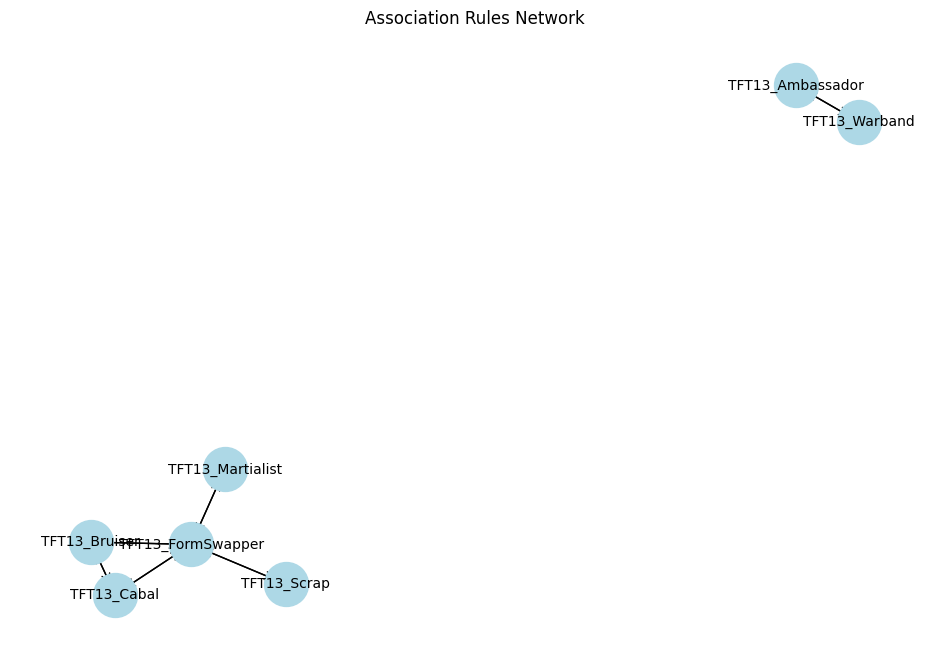

In [11]:
#Visualization
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for idx, row in rules.iterrows():
    antecedent_items = list(row['antecedents'])
    consequent_items = list(row['consequents'])
    
    for a_item in antecedent_items:
        for c_item in consequent_items:
            G.add_node(a_item)
            G.add_node(c_item)
            
           
            G.add_edge(a_item, c_item, lift=row['lift'], confidence=row['confidence'])


pos = nx.spring_layout(G, k=0.3, seed=42)  


plt.figure(figsize=(12, 8))


nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='lightblue')
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15)


nx.draw_networkx_labels(G, pos, font_size=10)

#edge_labels = nx.get_edge_attributes(G, 'lift')

#nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Association Rules Network")
plt.axis('off')  # optional, hides the matplotlib axes
plt.show()